In [ ]:
#Libraries
import rasterio as rast
import rasterio.mask
from rasterio.plot import show
from rasterio.enums import ColorInterp
from rasterio.transform import xy
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter
from pyproj import Transformer
from shapely import Point
import google.colab.drive

In [ ]:
#import files
buffer = gpd.read_file("/content/drive/MyDrive/SilvX Labs - Internship/Validation_Plots_Final.gpkg",
                       layer='0.5Mile_Buffer')
predictions = rast.open("/content/drive/MyDrive/SilvX Labs - Internship/lolo_nf_lolo_nf_inference_CORE_VARS_lolo_nf_16_mosaic.tif")

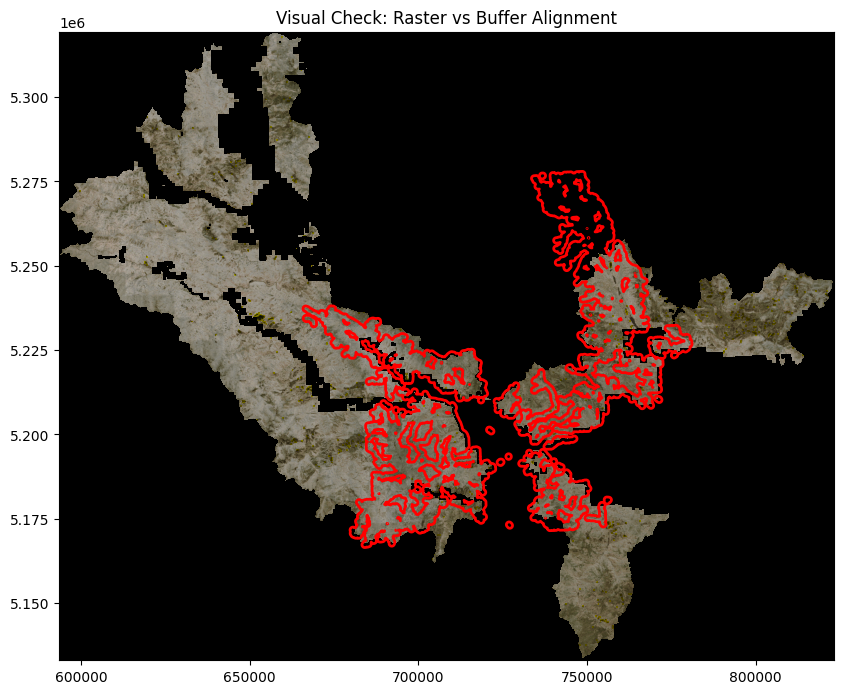

In [ ]:
#align CRS
crs = predictions.crs
buffer = buffer.to_crs(crs)

#dissolve buffer
buffer = buffer.dissolve()

#check
fig, ax = plt.subplots(figsize=(10, 10))

show(predictions, ax=ax, cmap='terrain')

buffer.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

plt.title("Visual Check: Raster vs Buffer Alignment")
plt.show()

In [ ]:
#Check Available Bands and pick one
print("Number of bands:", predictions.count)
print("Band Indexes:", predictions.indexes)
print("Band Descriptions:", predictions.descriptions)
selected_band = 13

Number of bands: 19
Band Indexes: (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19)
Band Descriptions: ('max_ht_all', 'max_ht_live', 'max_ht_dead', 'tpa_all_all', 'tpa_all_live', 'tpa_all_dead', 'tpa_over5_all', 'tpa_over5_live', 'tpa_over5_dead', 'tpa_over17_all', 'tpa_over17_live', 'tpa_over17_dead', 'basal_area_all', 'basal_area_all_live', 'basal_area_all_dead', 'basal_area_over5_all', 'basal_area_over5_live', 'basal_area_over5_dead', 'fortypcd')


In [ ]:
#clip raster to 0.5mile buffer

nodata = predictions.nodata

# Clip raster (returns a tuple: (array, transform))
clipped_predictions, clipped_transform = rasterio.mask.mask(
    predictions,
    buffer.geometry,
    crop=True,
    filled=True,
    nodata=nodata
)

# Convert to float for NaN handling
clipped_float = clipped_predictions[selected_band - 1].astype("float32")

# Replace nodata with np.nan
if nodata is not None:
    clipped_float[clipped_float == nodata] = np.nan

In [ ]:
#mask values outside desired range

min_val_ig = 35
max_val_ig = 59.9
min_val_og = 60
max_val_og = 85

#output for oldgrowth
desired_og = np.where(
    (clipped_float >= min_val_og) & (clipped_float <= max_val_og),
    clipped_float,
    np.nan
)

#output for intermediate growth
desired_ig = np.where(
    (clipped_float >= min_val_ig) & (clipped_float <= max_val_ig),
    clipped_float,
    np.nan
)

In [ ]:
#compute neighbor pixel similarity

#function creation
def similar_neighbors(window):
    center = window[len(window)//2]
    if np.isnan(center):
      return 0
    return np.sum(np.isnan(window))

#neighbor ID for oldgrowth
similarity_og = generic_filter(
    desired_og,
    similar_neighbors,
    size = 3,
    mode="constant",
    cval=np.nan
)

homogeneous_og = np.where(
    similarity_og == 0,
    desired_og,
    np.nan
    ).astype("float32")

#neighbor ID for intermediate growth
similarity_ig = generic_filter(
    desired_ig,
    similar_neighbors,
    size = 3,
    mode="constant",
    cval=np.nan
)

homogeneous_ig = np.where(
    similarity_ig == 0,
    desired_ig,
    np.nan
    ).astype("float32")

In [ ]:
#export oldgrowth raster

out_meta = predictions.meta.copy()
out_meta.update({
    "height": homogeneous_og.shape[0],
    "width": homogeneous_og.shape[1],
    "count": 1,
    "dtype": "uint8",
    "transform": clipped_transform,
    "nodata": 0
})

with rasterio.open(f"BA-All-3x3_og.tif", "w", **out_meta) as dst:
    dst.write(homogeneous_og, 1)

#export intermediate growth raster

out_meta = predictions.meta.copy()
out_meta.update({
    "height": homogeneous_ig.shape[0],
    "width": homogeneous_ig.shape[1],
    "count": 1,
    "dtype": "uint8",
    "transform": clipped_transform,
    "nodata": 0
})

with rasterio.open(f"BA-All-3x3_ig.tif", "w", **out_meta) as dst:
    dst.write(homogeneous_ig, 1)

/usr/local/lib/python3.12/dist-packages/numpy/_core/_asarray.py:126: RuntimeWarning: invalid value encountered in cast
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)


In [ ]:
#load eligible pixel raster
input_path_og = "/content/BA-All-3x3_og.tif"
input_path_ig = "/content/BA-All-3x3_ig.tif"
output_path_og = "/content/og_plots.tif"
output_path_ig = "/content/ig_plots.tif"

# Open old growth raster
with rasterio.open(input_path_og) as og:
    raster_og = og.read(1)
    profile_og = og.profile
    transform_og = og.transform
    crs_og = og.crs

# Open intermediate growth raster
with rasterio.open(input_path_ig) as ig:
    raster_ig = ig.read(1)
    profile_ig = ig.profile
    transform_ig = ig.transform
    crs_ig = ig.crs

In [ ]:
#Pixel Eligibility Masks

eligible_mask_og = (raster_og >= 60) & (raster_og <= 85)
eligible_mask_ig = (raster_ig >= 35) & (raster_ig <=59.9)

In [ ]:
#random sample eligible pixles

#old growth
rows_og, cols_og = np.where(eligible_mask_og)

percentage = 0.15
n_select_og = int(len(rows_og) * percentage)

selected_idx_og = np.random.choice(
    len(rows_og),
    size=n_select_og,
    replace=False
)

#intermediate growth
rows_ig, cols_ig = np.where(eligible_mask_ig)

percentage = 0.05
n_select_ig = int(len(rows_ig) * percentage)

selected_idx_ig = np.random.choice(
    len(rows_ig),
    size=n_select_ig,
    replace=False
)

In [ ]:
#Create Masks
#old growth
plot_mask_og = np.zeros_like(raster_og, dtype=np.uint8)
plot_mask_og[rows_og[selected_idx_og], cols_og[selected_idx_og]] = 1

#intermediate growth
plot_mask_ig = np.zeros_like(raster_ig, dtype=np.uint8)
plot_mask_ig[rows_ig[selected_idx_ig], cols_ig[selected_idx_ig]] = 1

#impliment
raster_og = raster_og.astype(float)  # convert to float for NaN
masked_raster_og = np.where(plot_mask_og == 1, raster_og, np.nan)

raster_ig = raster_ig.astype(float)  # convert to float for NaN
masked_raster_ig = np.where(plot_mask_ig == 1, raster_ig, np.nan)

In [ ]:
#Export masked rasters

#old growth
profile_og.update(dtype=rasterio.float32, nodata=np.nan, count=1)
with rasterio.open(output_path_og, "w", **profile_og) as dst:
    dst.write(masked_raster_og.astype(rasterio.float32), 1)

print("Selected pixels:", plot_mask_og.sum())
print("Masked raster exported!")

#intermediate growth
profile_ig.update(dtype=rasterio.float32, nodata=np.nan, count=1)
with rasterio.open(output_path_ig, "w", **profile_ig) as dst:
    dst.write(masked_raster_ig.astype(rasterio.float32), 1)

print("Selected pixels:", plot_mask_ig.sum())
print("Masked raster exported!")

Selected pixels: 63
Masked raster exported!
Selected pixels: 204
Masked raster exported!


In [ ]:
#extract coordinate locations at plot pixels and transform to lat long

#old growth
rows_selected_og, cols_selected_og = np.where(plot_mask_og == 1)
xs_og, ys_og = xy(transform_og,
            rows_selected_og,
            cols_selected_og,
            offset='center'
)

transformer_og = Transformer.from_crs(crs_og, "EPSG:4326", always_xy=True)
lons_og, lats_og = transformer_og.transform(xs_og, ys_og)

#intermediate growth
rows_selected_ig, cols_selected_ig = np.where(plot_mask_ig == 1)
xs_ig, ys_ig = xy(transform_ig,
            rows_selected_ig,
            cols_selected_ig,
            offset='center'
)

transformer_ig = Transformer.from_crs(crs_ig, "EPSG:4326", always_xy=True)
lons_ig, lats_ig = transformer_ig.transform(xs_ig, ys_ig)


In [ ]:
#save to CSV
output_csv_og = "/content/og_latlong.csv"
output_csv_ig = "/content/ig_latlong.csv"

#old growth
df_og = pd.DataFrame({
    "x_utm": xs_og,
    "y_utm": ys_og,
    "longitude": lons_og,
    "latitude": lats_og
})

df_og.to_csv(output_csv_og, index=False)
print("Plot locations CSV exported:", output_csv_og)

#intermediate growth
df_ig = pd.DataFrame({
    "x_utm": xs_ig,
    "y_utm": ys_ig,
    "longitude": lons_ig,
    "latitude": lats_ig
})

df_ig.to_csv(output_csv_ig, index=False)
print("Plot locations CSV exported:", output_csv_ig)

Plot locations CSV exported: /content/og_latlong.csv
Plot locations CSV exported: /content/ig_latlong.csv
